# Module 3 — The Response Function

This is the heart of the model. Modules 1 and 2 were plumbing: build the curve, price
options off it. **This module is the actual risk model** — the thing that answers *"if
SPX falls 20%, where does the VIX curve go?"*

If you can explain this module clearly, you can explain the model.

## The whole thing in one sentence

> **For a given SPX move, the model says how many VIX points each part of the curve
> moves — using three dials, fitted to 22 years of history, deliberately calibrated to
> the worst observed outcomes rather than the average ones.**

That is it. Three dials for down moves, two for up moves. Everything else is detail
about how those dials were set.

No symbolic formulas below. Dials, numbers and tables.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "learning" else Path.cwd()
sys.path.insert(0, str(REPO))
pd.set_option("display.width", 200)

from vixshock.response import load_params, beta_of_tenor

P = load_params()
print("the model's fitted parameters, loaded from output/response_params.json")
print(f"  fitted on {P.n_obs:,} observations, {P.fit_start} to {P.fit_end}")

the model's fitted parameters, loaded from output/response_params.json
  fitted on 112,910 observations, 2004-03-29 to 2026-09-18


## Step 1 — the three dials, in plain language

Forget the parameter names. Here is what each one *does*.

| dial | code name | value | what it controls |
|---|---|---|---|
| **1. Strength** | `beta_0` | 192 | how hard the front of the curve reacts to a small move |
| **2. Convexity** | `k` | 0.90 | whether big drops hurt *more than proportionally* |
| **3. Tenor fade** | `lam` | 0.20 | how much less the back of the curve moves than the front |

Plus two more for **rallies** (SPX up), which are fitted separately and more simply:
strength `beta_up_0` = 70 and fade `lam_up` = 0.23. No convexity dial on the up side —
the model uses a straight line for rallies.

Run the cell to see each dial translated into something you can say out loud.

In [2]:
front = beta_of_tenor(30, P.beta_0, P.lam)

print("DIAL 1 - STRENGTH")
print(f"  A 1% SPX drop moves the 30-day VIX future by about {front*0.01:.2f} points.")
print(f"  (So a 1% drop with VIX at 18 takes it to about {18+front*0.01:.1f}.)\n")

print("DIAL 2 - CONVEXITY")
print("  Big drops hurt MORE than proportionally. Compare a straight line to the model:\n")
rows = []
for r in (0.05, 0.10, 0.15, 0.20):
    straight = front * r
    actual = float(P.dvix(-r, 30))
    rows.append({"SPX drop": f"-{r*100:.0f}%", "straight line": round(straight,1),
                 "model": round(actual,1), "extra from convexity": round(actual-straight,1),
                 "ratio": f"{actual/straight:.2f}x"})
print(pd.DataFrame(rows).to_string(index=False))
print("\n  Note how MILD this is - only 10% extra at -20%. More on that below.\n")

print("DIAL 3 - TENOR FADE")
print("  The back of the curve moves less than the front:\n")
rows = []
for T in (30, 60, 90, 120):
    b = beta_of_tenor(T, P.beta_0, P.lam)
    rows.append({"tenor": f"{T}d", "% of front's move": f"{b/front*100:.0f}%",
                 "pts at SPX -10%": round(float(P.dvix(-0.10, T)),1),
                 "pts at SPX -20%": round(float(P.dvix(-0.20, T)),1)})
print(pd.DataFrame(rows).to_string(index=False))

DIAL 1 - STRENGTH
  A 1% SPX drop moves the 30-day VIX future by about 1.57 points.
  (So a 1% drop with VIX at 18 takes it to about 19.6.)

DIAL 2 - CONVEXITY
  Big drops hurt MORE than proportionally. Compare a straight line to the model:

SPX drop  straight line  model  extra from convexity ratio
     -5%            7.8    8.0                   0.2 1.02x
    -10%           15.7   16.4                   0.7 1.05x
    -15%           23.5   25.2                   1.7 1.07x
    -20%           31.4   34.4                   3.0 1.10x

  Note how MILD this is - only 10% extra at -20%. More on that below.

DIAL 3 - TENOR FADE
  The back of the curve moves less than the front:

tenor % of front's move  pts at SPX -10%  pts at SPX -20%
  30d              100%             16.4             34.4
  60d               82%             13.4             28.1
  90d               67%             11.0             23.0
 120d               55%              9.0             18.8


### Worth knowing: the convexity is milder than people expect

Ask anyone about VIX in a crash and they will describe an explosion. The model says a
-20% SPX move produces only **10% more** than a straight line would.

That is not the model being timid. It is the difference between **spot VIX** and **VIX
futures**. In March 2020 spot VIX printed 82 while the 30-day future capped near 70 —
the futures market simply did not believe panic would persist for 30 days. The violent
convexity everyone pictures lives in spot, and VIX options price off the **future**.

This is a good thing to say unprompted. It shows you know which instrument you are
modelling and why.

## Step 2 — the whole model on one grid

Those five dials produce this table, and this table *is* the risk model output.

In [3]:
import config

grid = pd.DataFrame(
    {f"CM-{T}": [round(float(P.dvix(s, T)),1) for s in config.SHOCKS] for T in config.TENORS},
    index=[f"{s:+.0%}" for s in config.SHOCKS])
grid.index.name = "SPX move"
print("VIX POINTS ADDED TO EACH PART OF THE CURVE:\n")
print(grid.to_string())
print("\nRead it: SPX -20% adds 34.4 points to the 30-day future and 18.8 to the 120-day.")
print("Rallies subtract points, and by much less - a +20% rally only takes 11.1 off the front.")

VIX POINTS ADDED TO EACH PART OF THE CURVE:

          CM-30  CM-60  CM-90  CM-120
SPX move                             
-40%       75.5   61.8   50.5    41.3
-35%       64.5   52.8   43.2    35.3
-30%       54.0   44.2   36.2    29.6
-25%       44.0   36.0   29.4    24.1
-20%       34.4   28.1   23.0    18.8
-15%       25.2   20.6   16.9    13.8
-10%       16.4   13.4   11.0     9.0
-5%         8.0    6.6    5.4     4.4
+5%        -2.8   -2.2   -1.7    -1.4
+10%       -5.5   -4.4   -3.5    -2.8
+15%       -8.3   -6.6   -5.2    -4.1
+20%      -11.1   -8.8   -7.0    -5.5
+25%      -13.8  -11.0   -8.7    -6.9
+30%      -16.6  -13.2  -10.4    -8.3
+35%      -19.4  -15.4  -12.2    -9.7
+40%      -22.2  -17.6  -13.9   -11.0

Read it: SPX -20% adds 34.4 points to the 30-day future and 18.8 to the 120-day.
Rallies subtract points, and by much less - a +20% rally only takes 11.1 off the front.


### The up/down asymmetry is deliberate and worth explaining

A -20% move adds 34.4 points to the front. A +20% move removes only 11.1. The model
reacts **three times harder to drops than to rallies.**

That is not a bug — it is how volatility actually behaves (the well-known leverage
effect: markets fall fast and rise slowly, and vol follows). But there is an important
asymmetry in *rigour* that you should flag yourself:

- The **down** branch is fitted to the worst observed outcomes (conservative).
- The **up** branch is fitted to the *average* outcome (not conservative).

So for a book that **loses money in a rally** — which a long-VIX-call book does — the
model's rally scenario is a central estimate, not a stress. README limitation 6 says
this. Check which way your book leans.

## Step 3 — how the dials were set: the envelope

You already guessed this correctly: **we fit to the worst cases, not the average ones.**
Here is exactly what that means mechanically.

Take every historical window where SPX fell about 9.5%. There are 346 of them. They did
not all produce the same VIX move — some produced 3 points, some produced 17. So which
number goes in the model?

In [4]:
env = pd.DataFrame(P.envelope_points[30])

show = env[["bin_lo", "bin_hi", "n", "r_mean", "y_mean", "y_env", "y_max"]].copy()
show.columns = ["bin from", "bin to", "# windows", "avg SPX move",
                "AVERAGE dVIX", "95th PCTILE (used)", "WORST dVIX"]
show = show.round(2)

print("THE ENVELOPE TABLE for the 30-day point.")
print("Every historical window, bucketed by how far SPX fell:\n")
print(show.tail(14).to_string(index=False))
print("\n(showing the smaller moves - there are 30 buckets in total)")

row = env[(env["bin_lo"] <= -0.095) & (env["bin_hi"] >= -0.095)].iloc[0]
print(f"\n--- Read one row: SPX fell about {abs(row['r_mean'])*100:.1f}% ---")
print(f"  that happened in {int(row['n'])} windows")
print(f"  the AVERAGE VIX move was      {row['y_mean']:5.2f} points")
print(f"  the 95th percentile was       {row['y_env']:5.2f} points   <- THE MODEL USES THIS")
print(f"  the worst single one was      {row['y_max']:5.2f} points")
print(f"\n  The model is calibrated {row['y_env']/row['y_mean']:.1f}x higher than average behaviour.")

THE ENVELOPE TABLE for the 30-day point.
Every historical window, bucketed by how far SPX fell:

 bin from  bin to  # windows  avg SPX move  AVERAGE dVIX  95th PCTILE (used)  WORST dVIX
    -0.14   -0.13         71         -0.14         10.32               20.10       25.69
    -0.13   -0.12         99         -0.12         10.54               20.59       31.61
    -0.12   -0.11        173         -0.11          8.98               16.52       24.95
    -0.11   -0.10        250         -0.11          8.22               14.21       19.07
    -0.10   -0.09        346         -0.09          6.85               12.57       17.70
    -0.09   -0.08        487         -0.08          5.91               12.74       19.89
    -0.08   -0.07        714         -0.07          5.72               12.24       22.80
    -0.07   -0.06       1067         -0.06          4.95               10.22       18.12
    -0.06   -0.05       1532         -0.05          3.98                8.79       18.08
    -0.05   -

### Why not just fit the average?

Because **a least-squares fit sits in the middle of the cloud — so by construction, half
of history produced a bigger VIX move than it predicts.** For a risk measure that is the
wrong side to be wrong on.

The model prints the comparison on every run so nobody has to take it on faith.

In [5]:
from vixshock.response import fit_response
from vixshock.join import load_pooled

pool = load_pooled()
lsq = fit_response(pool, method="lsq")

rows = []
for name, prm in (("envelope (USED)", P), ("least squares (not used)", lsq)):
    rows.append({"fit": name,
                 "CM-30 at -10%": round(float(prm.dvix(-0.10,30)),1),
                 "CM-30 at -20%": round(float(prm.dvix(-0.20,30)),1),
                 "CM-120 at -20%": round(float(prm.dvix(-0.20,120)),1)})
print("WHAT THE CHOICE COSTS:\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nThe envelope roughly DOUBLES the shock. That is the deliberate conservatism.")
print("\nIt is a named, switchable setting: config.DOWN_BRANCH_FIT and ENVELOPE_QUANTILE.")

WHAT THE CHOICE COSTS:

                     fit  CM-30 at -10%  CM-30 at -20%  CM-120 at -20%
         envelope (USED)           16.4           34.4            18.8
least squares (not used)            7.8           18.8             9.8

The envelope roughly DOUBLES the shock. That is the deliberate conservatism.

It is a named, switchable setting: config.DOWN_BRANCH_FIT and ENVELOPE_QUANTILE.


### The number that proves the conservatism is real

"We calibrate to the worst case" is a claim. **Coverage** is the measurement that backs
it: of all historical windows where SPX fell more than 2%, what share produced a VIX move
*at or below* what the model predicts?

This is the single best statistic to quote. Memorise it.

In [6]:
rows = []
for T, v in P.per_tenor.items():
    rows.append({"tenor": f"{T}d",
                 "coverage": f"{v['joint_coverage_down']*100:.1f}%",
                 "R2 on envelope points": round(v["joint_r2_env_points"], 3),
                 "R2 up branch": round(v["joint_r2_up"], 3)})
print("MODEL QUALITY BY TENOR:\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nCOVERAGE ~94%: of every historical selloff beyond 2%, ~94% produced a VIX move")
print("at or below what this model predicts. That is the conservatism, measured.")
print("\nR2 0.94 on the envelope points: the curve shape genuinely fits the worst cases.")
print("\nNOTE the up branch R2 is only ~0.23-0.37. Rallies are much noisier, and the")
print("model explains them far less well. Another reason the up branch is the weak side.")

MODEL QUALITY BY TENOR:

tenor coverage  R2 on envelope points  R2 up branch
  30d    94.6%                  0.946         0.370
  60d    94.5%                  0.937         0.309
  90d    93.8%                  0.939         0.273
 120d    91.5%                  0.940         0.234

COVERAGE ~94%: of every historical selloff beyond 2%, ~94% produced a VIX move
at or below what this model predicts. That is the conservatism, measured.

R2 0.94 on the envelope points: the curve shape genuinely fits the worst cases.

NOTE the up branch R2 is only ~0.23-0.37. Rallies are much noisier, and the
model explains them far less well. Another reason the up branch is the weak side.


## Step 4 — pooling: why windows of every length

Your guess was right: **so that windows actually contain big moves.** Here is the
evidence, and it is stronger than just "we needed more data."

The shock is defined as *"SPX moves X% over a window of up to 20 trading days."* The fit
stacks windows of **every** length from 1 to 20 days and takes the envelope over the
whole pile.

Why not pick one window length? Because **every single fixed length is broken**, and the
model prints this comparison on every run.

In [7]:
rows = []
for h in (1, 5, 10, 20):
    p = fit_response(pool[pool["horizon"] == h], horizon=str(h))
    rows.append({"window length": f"{h} day(s)", "convexity dial": round(p.k,2),
                 "CM-30 at -10%": round(float(p.dvix(-0.10,30)),1),
                 "CM-30 at -20%": round(float(p.dvix(-0.20,30)),1)})
rows.append({"window length": "POOLED 1-20 (used)", "convexity dial": round(P.k,2),
             "CM-30 at -10%": round(float(P.dvix(-0.10,30)),1),
             "CM-30 at -20%": round(float(P.dvix(-0.20,30)),1)})

print("FITTING ON A SINGLE WINDOW LENGTH - every one fails differently:\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\n  1-day  : no 1-day window in history contains a -20% move, so the fit")
print("           EXTRAPOLATES wildly. Convexity dial pins at its maximum (5.0).")
print("  5-day  : gives 12.3 at -20%. Absurdly LOW - it saturates.")
print("  10/20d : windows ending AFTER the VIX peak still carry a very negative SPX")
print("           return but a shrunken VIX move, dragging the envelope down.")
print("\n  POOLED : the only one that covers March 2020, which actually delivered +33 to +44.")

FITTING ON A SINGLE WINDOW LENGTH - every one fails differently:

     window length  convexity dial  CM-30 at -10%  CM-30 at -20%
          1 day(s)            5.00           19.7           52.2
          5 day(s)          -19.29           10.8           12.3
         10 day(s)           -0.51           13.5           26.4
         20 day(s)           -4.41           14.9           24.4
POOLED 1-20 (used)            0.90           16.4           34.4

  1-day  : no 1-day window in history contains a -20% move, so the fit
           EXTRAPOLATES wildly. Convexity dial pins at its maximum (5.0).
  5-day  : gives 12.3 at -20%. Absurdly LOW - it saturates.
  10/20d : windows ending AFTER the VIX peak still carry a very negative SPX
           return but a shrunken VIX move, dragging the envelope down.

  POOLED : the only one that covers March 2020, which actually delivered +33 to +44.


### The honest caveat on pooling — know this before someone asks

The obvious challenge is: **"Your windows overlap, so you are double-counting. That n of
112,870 is not 112,870 independent observations."**

**That challenge is correct.** Concede it immediately and completely:

> *"Yes — the windows overlap heavily, so the effective sample size is far below the
> nominal count and you cannot read a standard error off this fit. But the fit isn't
> being used for statistical inference. It's tracing an envelope. The quantity we want is
> 'the worst VIX response ever observed for an SPX move of this size, however fast it
> happened' — and pooling is what removes the horizon from that definition."*

Then point at the table above: we did not choose pooling because it gave a bigger number,
we chose it because **every fixed horizon is demonstrably broken** and pooling is the only
specification consistent with how the shock is defined.

**Never quote confidence intervals on these parameters.** That is the trap this caveat
protects you from.

## Step 5 — see it

Grey dots are every historical window. Red dots are the envelope (the 95th percentile in
each 1% bucket). The black line is the fitted model.

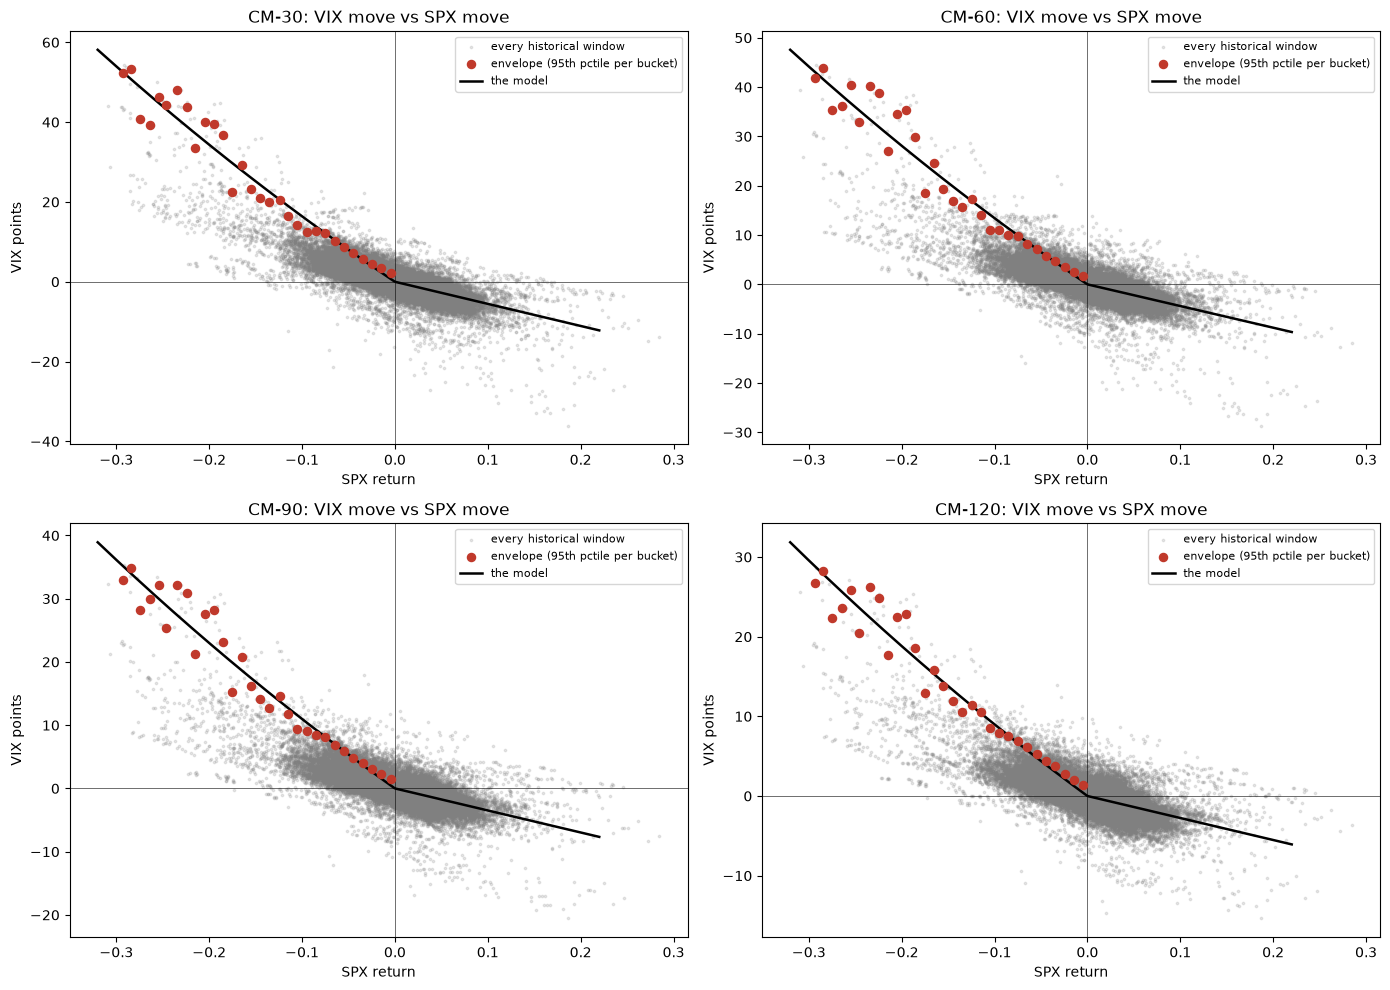

The black line rides the TOP of the grey cloud on the left side - that is the
conservatism, visible. On the right side (rallies) it runs through the MIDDLE,
because the up branch is an average fit. You can see the asymmetry in rigour.


In [8]:
import matplotlib.pyplot as plt
from vixshock.response import h_down

d = pool.loc[P.fit_start:P.fit_end]
r = d["spx_ret"].to_numpy()
gridx = np.linspace(-0.32, 0.22, 400)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, T in zip(axes.ravel(), config.TENORS):
    y = d[f"dvix_{T}"].to_numpy()
    ax.scatter(r, y, s=3, alpha=0.18, color="grey", label="every historical window")
    e = pd.DataFrame(P.envelope_points[T])
    ax.scatter(e["r_mean"], e["y_env"], s=34, color="#c0392b", zorder=5,
               label="envelope (95th pctile per bucket)")
    ax.plot(gridx, P.dvix(gridx, T), color="black", lw=1.8, label="the model")
    ax.axhline(0, color="k", lw=0.4); ax.axvline(0, color="k", lw=0.4)
    ax.set_title(f"CM-{T}: VIX move vs SPX move")
    ax.set_xlabel("SPX return"); ax.set_ylabel("VIX points")
    ax.legend(fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

print("The black line rides the TOP of the grey cloud on the left side - that is the")
print("conservatism, visible. On the right side (rallies) it runs through the MIDDLE,")
print("because the up branch is an average fit. You can see the asymmetry in rigour.")

## Step 6 — the weakness the model flags about itself

Every run prints a warning. You should know what it says before someone else reads it
out to you.

In [9]:
rows = []
for name, a, b in [("2004-now (SHIPPED)", config.FIT_START, None),
                   ("2013-now", "2013-01-01", None),
                   ("2004-2012", config.FIT_START, "2012-12-31")]:
    p = fit_response(pool, fit_start=a, fit_end=b)
    rows.append({"calibration window": name, "strength dial": round(p.beta_0),
                 "CM-30 at -10%": round(float(p.dvix(-0.10,30)),1),
                 "CM-30 at -20%": round(float(p.dvix(-0.20,30)),1)})
print("REGIME INSTABILITY - the same method on different eras:\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nThe post-2012 market reacts HARDER than the shipped full-sample calibration.")
print("So the shipped numbers are LESS conservative than a recent-data fit would be.")
print("\nThe run prints this as a warning. Say it before anyone asks:")
print("  'Full sample is the spec default, but post-2012 is the more conservative")
print("   calibration and it is one config flag away: config.FIT_START.'")

REGIME INSTABILITY - the same method on different eras:

calibration window  strength dial  CM-30 at -10%  CM-30 at -20%
2004-now (SHIPPED)            192           16.4           34.4
          2013-now            227           18.6           37.3
         2004-2012            251           13.9           19.7

The post-2012 market reacts HARDER than the shipped full-sample calibration.
So the shipped numbers are LESS conservative than a recent-data fit would be.

The run prints this as a warning. Say it before anyone asks:
  'Full sample is the spec default, but post-2012 is the more conservative
   calibration and it is one config flag away: config.FIT_START.'


## Step 7 — where the model's coverage ends

This connects the response function directly to the far-OTM finding. **This is the most
important cell in the notebook for the Monday conversation.**

The response function determines the highest VIX level any scenario can produce. That
sets a boundary on which strikes the model can ever see go in the money.

> **Note — the scenario grid changed after this notebook was first written.** It used to
> stop at −20%; `config.SHOCKS` now runs to **−40%**. That matters for how you phrase the
> finding, so the cell below reads the grid live rather than assuming. Read the two
> boundaries it prints carefully: they are different things and conflating them would
> weaken your argument.

In [10]:
from vixshock.cm import load_cm

cm = load_cm()
base = {T: float(cm[f"cm_{T}"].dropna().iloc[-1]) for T in config.TENORS}
worst = min(config.SHOCKS)   # the grid now runs to -40%

print(f"HIGHEST FORWARD THE MODEL CAN PRODUCE, by tenor")
print(f"(scenario grid currently runs to {worst:.0%})\n")
rows = []
for T in config.TENORS:
    rows.append({"tenor": f"{T}d", "base": round(base[T], 2),
                 "at -20%": round(base[T] + float(P.dvix(-0.20, T)), 1),
                 "at -30%": round(base[T] + float(P.dvix(-0.30, T)), 1),
                 f"at {worst:.0%} (grid max)": round(base[T] + float(P.dvix(worst, T)), 1)})
print(pd.DataFrame(rows).to_string(index=False))

HIST_MAX_CM30 = 69.87    # 2020-03-18, the highest the 30-day future has ever closed
HIST_MAX_SPOT = 82.69    # 2020-03-16 spot VIX

p20 = base[30] + float(P.dvix(-0.20, 30))
pmx = base[30] + float(P.dvix(worst, 30))
print(f"\nHistorical maxima:  spot VIX {HIST_MAX_SPOT}  |  30-day FUTURE {HIST_MAX_CM30}")
print(f"Model at -20%: {p20:.0f}     Model at {worst:.0%}: {pmx:.0f}")

print("\nTWO DIFFERENT BOUNDARIES - do not confuse them:\n")
print(f"  1. CREDIBLE reach.  Up to about -30% the model stays inside what history")
print(f"     has shown (30-day future max {HIST_MAX_CM30}). Past that it is extrapolating")
print(f"     beyond any observed state - config.SHOCKS says so explicitly.")
print(f"\n  2. The scenario GRID now runs to {worst:.0%}, which reaches {pmx:.0f} at the front.")
print(f"     So the grid DOES nominally reach high strikes - but only in scenarios")
print(f"     the model itself flags as extrapolation.")

print("\nWHAT THIS MEANS FOR FAR-OTM CALLS:")
print("  A call struck above ~52 is out of reach of any CREDIBLE scenario (-20%).")
print(f"  It only comes into the money at {worst:.0%}-type shocks, where the model is")
print("  extrapolating past its calibration envelope and past market history.")
print("\n  So the risk shows up only in the least trustworthy column of the grid.")
print("  That is a weaker claim than 'never in the money' - and it is the honest one.")

HIGHEST FORWARD THE MODEL CAN PRODUCE, by tenor
(scenario grid currently runs to -40%)

tenor  base  at -20%  at -30%  at -40% (grid max)
  30d 17.75     52.1     71.7                93.2
  60d 18.68     46.8     62.9                80.4
  90d 19.15     42.2     55.3                69.7
 120d 19.80     38.6     49.4                61.2

Historical maxima:  spot VIX 82.69  |  30-day FUTURE 69.87
Model at -20%: 52     Model at -40%: 93

TWO DIFFERENT BOUNDARIES - do not confuse them:

  1. CREDIBLE reach.  Up to about -30% the model stays inside what history
     has shown (30-day future max 69.87). Past that it is extrapolating
     beyond any observed state - config.SHOCKS says so explicitly.

  2. The scenario GRID now runs to -40%, which reaches 93 at the front.
     So the grid DOES nominally reach high strikes - but only in scenarios
     the model itself flags as extrapolation.

WHAT THIS MEANS FOR FAR-OTM CALLS:
  A call struck above ~52 is out of reach of any CREDIBLE scenario (

---

## What to take away

**The model in one sentence:** three dials — strength, convexity, tenor fade — turn an
SPX move into a VIX-points move for each part of the curve, fitted to 22 years of history
and deliberately calibrated to the worst observed outcomes.

**The numbers to have ready:**

- 1% SPX drop → about **1.6 VIX points** on the 30-day future
- SPX −20% → **+34.4** at 30 days, **+18.8** at 120 days
- The 120-day point moves about **55%** of what the front does
- **Coverage ~94.6%**: of all historical selloffs beyond 2%, that share produced a VIX
  move at or below the model's prediction
- **R² 0.94** on the envelope points at every tenor
- Envelope roughly **doubles** the shock versus a least-squares fit

**The three things to concede before being asked:**

1. **Overlapping windows** — no valid standard errors, do not quote confidence intervals.
   The fit traces an envelope, it does not do inference.
2. **Post-2012 reacts harder** than the shipped full-sample calibration (beta_0 227 vs
   192), so the shipped numbers are the *less* conservative choice. One config flag away.
3. **The up branch is an average fit**, not a conservative one, and explains far less
   (R² ~0.23–0.37 vs 0.94 down). Asymmetric rigour.

**The connection to your book — phrase this carefully.** The scenario grid now runs to
−40%, so far-OTM calls are not literally unreachable. The accurate statement is about
*credibility*, not reach:

> *"At −20%, which is the deepest shock still inside the calibration envelope, the front
> of the curve reaches about 52. Our calls struck above that only come into the money at
> −30% to −40%, where the model is extrapolating past its own calibration and past
> anything the VIX futures market has ever printed — the 30-day future's all-time high is
> 69.9. So the exposure appears only in the least trustworthy column of the grid."*

That is weaker than "never in the money," and it is the version that survives scrutiny.

**Code:** `vixshock/response.py`. The envelope is `envelope_points()`; the fit is
`fit_response()`. Report section 4.

---

### Questions to test yourself

1. Explain the envelope to someone who has never seen this model, in three sentences.
2. Someone says: "112,910 observations? Those windows overlap, your sample size is fake."
   Answer them.
3. Why is the convexity so mild (only 10% above a straight line at −20%) when everyone
   knows VIX explodes in a crash?
4. The model reacts 3× harder to a −20% drop than a +20% rally. Is that a flaw?
5. Your book is short far-OTM calls. Using what is in this module, explain in two
   sentences why the model does not give you a trustworthy number for that risk.